In [19]:
import subprocess
import sys

for pkg in ["eurostat", "pandas"]:
    try:
        __import__(pkg)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg])

import eurostat
import pandas as pd


In [20]:
# --- Fetch and prepare tour_ce_omn12 (tourism: overnight stays) ---
tourism_raw = eurostat.get_data_df('tour_ce_omn12')

# Normalise month column and rename geo
tourism_raw["month"] = tourism_raw["month"].str.replace(r'M', "", regex=True)
tourism_raw = tourism_raw.rename(columns={"geo\\TIME_PERIOD": "GEO"})

# Melt to long format
tourism_long = tourism_raw.melt(
    id_vars=['freq', 'indic_to', 'c_resid', 'month', 'unit', 'GEO'],
    var_name='TIME_PERIOD',
    value_name='bookings'
)

# Keep annual totals (month == "TOTAL") for overnight stays (STY)
# c_resid = TOTAL means domestic + foreign combined
tourism_annual = (
    tourism_long[
        (tourism_long['month'] == 'TOTAL') &
        (tourism_long['indic_to'] == 'STY')
    ]
    [['GEO', 'TIME_PERIOD', 'c_resid', 'bookings']]
    .dropna(subset=['bookings'])
)
tourism_annual['TIME_PERIOD'] = tourism_annual['TIME_PERIOD'].astype(str)

print("tour_ce_omn12 – annual overnight stays (first rows):")
print(tourism_annual.head())
print("Shape:", tourism_annual.shape)


tour_ce_omn12 – annual overnight stays (first rows):
        GEO TIME_PERIOD c_resid  bookings
35183    AT        2018     DOM  118630.0
35184   AT1        2018     DOM   44518.0
35185  AT11        2018     DOM    4452.0
35186  AT12        2018     DOM    7217.0
35187  AT13        2018     DOM   32849.0
Shape: (8085, 4)


In [21]:
# --- Fetch and prepare ilc_lvho07_r (housing cost overburden rate, NUTS regions) ---
housing_raw = eurostat.get_data_df('ilc_lvho07_r')

print("ilc_lvho07_r columns:", housing_raw.columns.tolist())
housing_raw.head()


ilc_lvho07_r columns: ['freq', 'unit', 'geo\\TIME_PERIOD', '2021', '2022', '2023', '2024', '2025']


,freq,unit,geo\TIME_PERIOD,2021,2022,2023,2024,2025
0,A,PC,AL,3.3,2.8,2.1,NaN,NaN
1,A,PC,AT,6.1,7.4,6.0,6.3,NaN
2,A,PC,BE,7.6,7.5,7.8,6.7,6.7
3,A,PC,BE1,15.7,17.3,15.9,16.6,16.6
4,A,PC,BE10,15.7,17.3,15.9,16.6,16.6


In [22]:
# Identify the geo column (Eurostat names it "geo\TIME_PERIOD")
geo_col = [c for c in housing_raw.columns if 'geo' in c.lower()][0]

housing_raw = housing_raw.rename(columns={geo_col: "GEO"})

# Melt year columns to long format
id_cols = [c for c in housing_raw.columns if not c.replace('.', '').isdigit()]
year_cols = [c for c in housing_raw.columns if c not in id_cols]

housing_long = housing_raw.melt(
    id_vars=id_cols,
    value_vars=year_cols,
    var_name='TIME_PERIOD',
    value_name='housing_cost_overburden_rate'
)
housing_long['TIME_PERIOD'] = housing_long['TIME_PERIOD'].astype(str)
housing_long = housing_long.dropna(subset=['housing_cost_overburden_rate'])

print("ilc_lvho07_r – long format (first rows):")
print(housing_long.head())
print("Shape:", housing_long.shape)
print("GEO sample:", housing_long['GEO'].unique()[:10])


ilc_lvho07_r – long format (first rows):
  freq unit   GEO TIME_PERIOD  housing_cost_overburden_rate
0    A   PC    AL        2021                           3.3
1    A   PC    AT        2021                           6.1
2    A   PC    BE        2021                           7.6
3    A   PC   BE1        2021                          15.7
4    A   PC  BE10        2021                          15.7
Shape: (1459, 5)
GEO sample: ['AL' 'AT' 'BE' 'BE1' 'BE10' 'BE2' 'BE21' 'BE22' 'BE23' 'BE24']


In [23]:
# --- Merge on GEO (NUTS region code) and TIME_PERIOD ---
# Left-join tourism onto housing so we keep all tourism region-year pairs
# and enrich with the housing cost overburden rate where available.

merged = pd.merge(
    tourism_annual,
    housing_long[['GEO', 'TIME_PERIOD', 'housing_cost_overburden_rate']],
    on=['GEO', 'TIME_PERIOD'],
    how='left'
)

print("Merged dataset (first rows):")
print(merged.head(10))
print("\nShape:", merged.shape)
print("\nNull count in housing_cost_overburden_rate:", merged['housing_cost_overburden_rate'].isna().sum())
print("\nCoverage (non-null housing values):",
      f"{merged['housing_cost_overburden_rate'].notna().sum()} / {len(merged)}")
merged


Merged dataset (first rows):
    GEO TIME_PERIOD c_resid  bookings  housing_cost_overburden_rate
0    AT        2018     DOM  118630.0                           NaN
1   AT1        2018     DOM   44518.0                           NaN
2  AT11        2018     DOM    4452.0                           NaN
3  AT12        2018     DOM    7217.0                           NaN
4  AT13        2018     DOM   32849.0                           NaN
5   AT2        2018     DOM   33927.0                           NaN
6  AT21        2018     DOM   12237.0                           NaN
7  AT22        2018     DOM   21690.0                           NaN
8   AT3        2018     DOM   40185.0                           NaN
9  AT31        2018     DOM   10166.0                           NaN

Shape: (8085, 5)

Null count in housing_cost_overburden_rate: 4641

Coverage (non-null housing values): 3444 / 8085


,GEO,TIME_PERIOD,c_resid,bookings,housing_cost_overburden_rate
0,AT,2018,DOM,118630.0,NaN
1,AT1,2018,DOM,44518.0,NaN
2,AT11,2018,DOM,4452.0,NaN
3,AT12,2018,DOM,7217.0,NaN
4,AT13,2018,DOM,32849.0,NaN
...,...,...,...,...,...
8080,SK0,2024,TOTAL,484406.0,NaN
8081,SK01,2024,TOTAL,173514.0,5.2
8082,SK02,2024,TOTAL,53016.0,4.9
8083,SK03,2024,TOTAL,133435.0,6.7


In [24]:
# --- Step 1: Filter to NUTS 2 level + TOTAL residency ---
# NUTS 2 = 4-character GEO codes (e.g. "AT11", "DE21")
# This is the granularity where most Eurostat regional datasets overlap.

tourism_nuts2 = (
    tourism_annual[
        (tourism_annual['GEO'].str.len() == 4) &
        (tourism_annual['c_resid'] == 'TOTAL')
    ]
    .copy()
    .reset_index(drop=True)
)

print("tourism_nuts2 shape:", tourism_nuts2.shape)
print("Years available:", sorted(tourism_nuts2['TIME_PERIOD'].unique()))
print("Sample GEOs:", tourism_nuts2['GEO'].unique()[:10])


tourism_nuts2 shape: (1799, 4)
Years available: ['2018', '2019', '2020', '2021', '2022', '2023', '2024']
Sample GEOs: ['AT11' 'AT12' 'AT13' 'AT21' 'AT22' 'AT31' 'AT32' 'AT33' 'AT34' 'BE10']


In [25]:
# --- Step 2: Population (demo_r_d2jan) — needed for per-capita bookings ---
# Total population, both sexes, all ages, NUTS 2, Jan 1 each year.
pop_raw = eurostat.get_data_df('demo_r_d2jan')

print("demo_r_d2jan columns:", pop_raw.columns.tolist())
print("Unique 'sex':", pop_raw['sex'].unique() if 'sex' in pop_raw.columns else "n/a")
print("Unique 'age':", pop_raw['age'].unique() if 'age' in pop_raw.columns else "n/a")
pop_raw.head(3)


demo_r_d2jan columns: ['freq', 'unit', 'sex', 'age', 'geo\\TIME_PERIOD', '1990', '1991', '1992', '1993', '1994', '1995', '1996', '1997', '1998', '1999', '2000', '2001', '2002', '2003', '2004', '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024', '2025']
Unique 'sex': ['F' 'M' 'T']
Unique 'age': ['TOTAL' 'UNK' 'Y1' 'Y10' 'Y11' 'Y12' 'Y13' 'Y14' 'Y15' 'Y16' 'Y17' 'Y18'
 'Y19' 'Y2' 'Y20' 'Y21' 'Y22' 'Y23' 'Y24' 'Y25' 'Y26' 'Y27' 'Y28' 'Y29'
 'Y3' 'Y30' 'Y31' 'Y32' 'Y33' 'Y34' 'Y35' 'Y36' 'Y37' 'Y38' 'Y39' 'Y4'
 'Y40' 'Y41' 'Y42' 'Y43' 'Y44' 'Y45' 'Y46' 'Y47' 'Y48' 'Y49' 'Y5' 'Y50'
 'Y51' 'Y52' 'Y53' 'Y54' 'Y55' 'Y56' 'Y57' 'Y58' 'Y59' 'Y6' 'Y60' 'Y61'
 'Y62' 'Y63' 'Y64' 'Y65' 'Y66' 'Y67' 'Y68' 'Y69' 'Y7' 'Y70' 'Y71' 'Y72'
 'Y73' 'Y74' 'Y75' 'Y76' 'Y77' 'Y78' 'Y79' 'Y8' 'Y80' 'Y81' 'Y82' 'Y83'
 'Y84' 'Y85' 'Y86' 'Y87' 'Y88' 'Y89' 'Y9' 'Y90' 'Y91' 'Y92' 'Y93' 'Y94'
 'Y95' 'Y96' 'Y97' '

,freq,unit,sex,age,geo\TIME_PERIOD,1990,1991,1992,1993,1994,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
0,A,NR,F,TOTAL,AL,NaN,NaN,NaN,NaN,NaN,...,1417141.0,1423050.0,1431715.0,1432833.0,1425342.0,1419759.0,1406532.0,1394864.0,NaN,1194597.0
1,A,NR,F,TOTAL,AL0,NaN,NaN,NaN,NaN,NaN,...,1417141.0,1423050.0,1431715.0,1432833.0,1425342.0,1419759.0,1406532.0,1394864.0,NaN,1194597.0
2,A,NR,F,TOTAL,AL01,NaN,NaN,NaN,NaN,NaN,...,406682.0,405835.0,405598.0,404201.0,399599.0,396799.0,390886.0,385462.0,NaN,317141.0


In [26]:
# Reshape population to long, keep total sex + total age at NUTS 2
geo_col_pop = [c for c in pop_raw.columns if 'geo' in c.lower()][0]
pop_raw = pop_raw.rename(columns={geo_col_pop: "GEO"})

id_cols_pop = [c for c in pop_raw.columns if not c.replace('.', '').isdigit()]
year_cols_pop = [c for c in pop_raw.columns if c not in id_cols_pop]

pop_long = pop_raw.melt(
    id_vars=id_cols_pop,
    value_vars=year_cols_pop,
    var_name='TIME_PERIOD',
    value_name='population'
)
pop_long['TIME_PERIOD'] = pop_long['TIME_PERIOD'].astype(str)
pop_long = pop_long.dropna(subset=['population'])

# Keep only total sex + total age + NUTS 2 regions
sex_col = 'sex' if 'sex' in pop_long.columns else None
age_col = 'age' if 'age' in pop_long.columns else None

mask = pop_long['GEO'].str.len() == 4
if sex_col:
    mask &= pop_long[sex_col] == 'T'
if age_col:
    mask &= pop_long[age_col] == 'TOTAL'

pop_nuts2 = pop_long[mask][['GEO', 'TIME_PERIOD', 'population']].copy()
pop_nuts2['population'] = pop_nuts2['population'].astype(float)

print("pop_nuts2 shape:", pop_nuts2.shape)
print(pop_nuts2.head(3))


pop_nuts2 shape: (10404, 3)
         GEO TIME_PERIOD  population
107209  AT11        1990    270670.0
107210  AT12        1990   1455968.0
107211  AT13        1990   1492636.0


In [27]:
# --- Step 3: GDP by NUTS 2 (nama_10r_2gdp) ---
# Unit MIO_EUR = GDP in million EUR; we'll derive GDP per capita after merging with population.
gdp_raw = eurostat.get_data_df('nama_10r_2gdp')

geo_col_gdp = [c for c in gdp_raw.columns if 'geo' in c.lower()][0]
gdp_raw = gdp_raw.rename(columns={geo_col_gdp: "GEO"})

print("nama_10r_2gdp columns:", gdp_raw.columns.tolist())
print("unit values:", gdp_raw['unit'].unique() if 'unit' in gdp_raw.columns else "n/a")


nama_10r_2gdp columns: ['freq', 'unit', 'GEO', '2000', '2001', '2002', '2003', '2004', '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024']
unit values: ['EUR_HAB' 'EUR_HAB_EU27_2020' 'MIO_EUR' 'MIO_NAC' 'MIO_PPS_EU27_2020'
 'PPS_EU27_2020_HAB' 'PPS_HAB_EU27_2020']


In [28]:
# Keep PPS_HAB (GDP per inhabitant in PPS) — directly comparable across regions
id_cols_gdp = [c for c in gdp_raw.columns if not c.replace('.', '').isdigit()]
year_cols_gdp = [c for c in gdp_raw.columns if c not in id_cols_gdp]

gdp_long = gdp_raw.melt(
    id_vars=id_cols_gdp,
    value_vars=year_cols_gdp,
    var_name='TIME_PERIOD',
    value_name='gdp_pps_per_hab'
)
gdp_long['TIME_PERIOD'] = gdp_long['TIME_PERIOD'].astype(str)
gdp_long = gdp_long.dropna(subset=['gdp_pps_per_hab'])

# Use PPS per inhabitant (EU=100 index) if available, else PPS_HAB
unit_vals = gdp_long['unit'].unique() if 'unit' in gdp_long.columns else []
print("unit values:", unit_vals)

# Prefer PPS_HAB (absolute) or MIO_PPS over index
preferred_unit = next((u for u in ['PPS_HAB', 'PPS_EU27_2020_HAB', 'MIO_PPS'] if u in unit_vals), unit_vals[0] if len(unit_vals) else None)
print("Using unit:", preferred_unit)

gdp_nuts2 = (
    gdp_long[
        (gdp_long['GEO'].str.len() == 4) &
        (gdp_long['unit'] == preferred_unit)
    ]
    [['GEO', 'TIME_PERIOD', 'gdp_pps_per_hab']]
    .copy()
)

print("gdp_nuts2 shape:", gdp_nuts2.shape)
print(gdp_nuts2.head(3))


unit values: ['EUR_HAB' 'EUR_HAB_EU27_2020' 'MIO_EUR' 'MIO_NAC' 'MIO_PPS_EU27_2020'
 'PPS_EU27_2020_HAB' 'PPS_HAB_EU27_2020']
Using unit: PPS_EU27_2020_HAB
gdp_nuts2 shape: (6896, 3)
       GEO TIME_PERIOD  gdp_pps_per_hab
2278  AT11        2000          16200.0
2279  AT12        2000          20000.0
2280  AT13        2000          33300.0


In [29]:
# --- Step 4: Unemployment rate by NUTS 2 (lfst_r_lfu3rt) ---
unemp_raw = eurostat.get_data_df('lfst_r_lfu3rt')
geo_col_u = [c for c in unemp_raw.columns if 'geo' in c.lower()][0]
unemp_raw = unemp_raw.rename(columns={geo_col_u: "GEO"})

print("lfst_r_lfu3rt columns:", unemp_raw.columns.tolist())
for col in ['sex', 'age', 'isced11', 'unit']:
    if col in unemp_raw.columns:
        print(f"  {col}:", unemp_raw[col].unique())


lfst_r_lfu3rt columns: ['freq', 'isced11', 'sex', 'age', 'unit', 'GEO', '1999', '2000', '2001', '2002', '2003', '2004', '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024']
  sex: ['F' 'M' 'T']
  age: ['Y15-24' 'Y15-29' 'Y15-74' 'Y20-64' 'Y25-34' 'Y35-44' 'Y45-54' 'Y55-64'
 'Y_GE15' 'Y_GE25']
  isced11: ['ED0-2' 'ED3_4' 'ED5-8' 'NRP' 'TOTAL' 'UNK']
  unit: ['PC']


In [30]:
id_cols_u = [c for c in unemp_raw.columns if not c.replace('.', '').isdigit()]
year_cols_u = [c for c in unemp_raw.columns if c not in id_cols_u]

unemp_long = unemp_raw.melt(
    id_vars=id_cols_u,
    value_vars=year_cols_u,
    var_name='TIME_PERIOD',
    value_name='unemployment_rate'
)
unemp_long['TIME_PERIOD'] = unemp_long['TIME_PERIOD'].astype(str)
unemp_long = unemp_long.dropna(subset=['unemployment_rate'])

# Keep total sex, 15–74 age group (or widest available), NUTS 2
mask_u = unemp_long['GEO'].str.len() == 4
if 'sex' in unemp_long.columns:
    mask_u &= unemp_long['sex'] == 'T'
if 'age' in unemp_long.columns:
    age_vals = unemp_long['age'].unique()
    total_age = next((a for a in ['TOTAL', 'Y15-74', 'Y_LT75'] if a in age_vals), age_vals[0])
    mask_u &= unemp_long['age'] == total_age
    print("Using age group:", total_age)

unemp_nuts2 = unemp_long[mask_u][['GEO', 'TIME_PERIOD', 'unemployment_rate']].copy()
print("unemp_nuts2 shape:", unemp_nuts2.shape)
print(unemp_nuts2.head(3))


Using age group: Y15-74
unemp_nuts2 shape: (28085, 3)
        GEO TIME_PERIOD  unemployment_rate
11267  AT12        1999                7.3
11268  AT13        1999               11.1
11271  AT22        1999                5.8


In [31]:
# --- Step 5: Tertiary education rate by NUTS 2 (tgs00109) ---
# Persons with tertiary educational attainment (ISCED 5-8), share of population 25-64 — NUTS 2.
# Note: edat_r_lfe2et is deprecated/unavailable; tgs00109 is the current regional equivalent.
edu_raw = eurostat.get_data_df('tgs00109')
geo_col_e = [c for c in edu_raw.columns if 'geo' in c.lower()][0]
edu_raw = edu_raw.rename(columns={geo_col_e: "GEO"})

print("tgs00109 columns:", edu_raw.columns.tolist())
for col in ['sex', 'age', 'isced11']:
    if col in edu_raw.columns:
        print(f"  {col}:", edu_raw[col].unique())
edu_raw.head(3)


tgs00109 columns: ['freq', 'unit', 'isced11', 'age', 'sex', 'GEO', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024']
  sex: ['F' 'M' 'T']
  age: ['Y25-64']
  isced11: ['ED5-8']


,freq,unit,isced11,age,sex,GEO,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,A,PC,ED5-8,Y25-64,F,AT11,14.4,24.8,26.7,27.1,28.3,28.4,30.5,32.4,31.3,31.9,34.1,35.5
1,A,PC,ED5-8,Y25-64,F,AT12,15.5,27.7,28.1,28.7,31.1,30.3,31.9,33.2,33.8,33.4,36.2,38.7
2,A,PC,ED5-8,Y25-64,F,AT13,30.7,40.3,39.3,41.2,43.6,43.4,44.9,44.7,46.1,47.1,47.5,49.4


In [32]:
id_cols_e = [c for c in edu_raw.columns if not c.replace('.', '').isdigit()]
year_cols_e = [c for c in edu_raw.columns if c not in id_cols_e]

edu_long = edu_raw.melt(
    id_vars=id_cols_e,
    value_vars=year_cols_e,
    var_name='TIME_PERIOD',
    value_name='tertiary_edu_rate'
)
edu_long['TIME_PERIOD'] = edu_long['TIME_PERIOD'].astype(str)
edu_long = edu_long.dropna(subset=['tertiary_edu_rate'])

# Keep total sex, NUTS 2
mask_e = edu_long['GEO'].str.len() == 4
if 'sex' in edu_long.columns:
    mask_e &= edu_long['sex'] == 'T'

edu_nuts2 = edu_long[mask_e][['GEO', 'TIME_PERIOD', 'tertiary_edu_rate']].copy()
print("edu_nuts2 shape:", edu_nuts2.shape)
print(edu_nuts2.head(3))


edu_nuts2 shape: (3732, 3)
      GEO TIME_PERIOD  tertiary_edu_rate
680  AT11        2013               15.8
681  AT12        2013               17.6
682  AT13        2013               30.6


In [33]:
# --- Step 6: Housing (ilc_lvho07_r) — re-filter to NUTS 2 ---
housing_nuts2 = (
    housing_long[housing_long['GEO'].str.len() == 4]
    [['GEO', 'TIME_PERIOD', 'housing_cost_overburden_rate']]
    .copy()
)
print("housing_nuts2 shape:", housing_nuts2.shape)


housing_nuts2 shape: (999, 3)


In [34]:
# --- Step 7: Build final analytical dataset ---
# Sequential left-joins on GEO + TIME_PERIOD, then per-capita transformation.

panel = tourism_nuts2.copy()

for df, label in [
    (pop_nuts2,      'population'),
    (gdp_nuts2,      'gdp_pps_per_hab'),
    (unemp_nuts2,    'unemployment_rate'),
    (edu_nuts2,      'tertiary_edu_rate'),
    (housing_nuts2,  'housing_cost_overburden_rate'),
]:
    panel = panel.merge(df, on=['GEO', 'TIME_PERIOD'], how='left')

# --- Per-capita transformation ---
# Bookings (overnight stays) per 100 000 residents — standard regional tourism metric.
# Using population as denominator removes size bias across NUTS 2 regions.
panel['bookings_per_100k'] = (panel['bookings'] / panel['population']) * 100_000

# --- Missing value report (before dropping) ---
print("=== Missing value counts ===")
print(panel.isnull().sum())
print(f"\nTotal rows: {len(panel)}")
print(f"Complete cases (no NaN): {panel.dropna().shape[0]}")


=== Missing value counts ===
GEO                                0
TIME_PERIOD                        0
c_resid                            0
bookings                           0
population                         5
gdp_pps_per_hab                  323
unemployment_rate                 71
tertiary_edu_rate                 50
housing_cost_overburden_rate    3460
bookings_per_100k                  5
dtype: int64

Total rows: 6017
Complete cases (no NaN): 2383


In [35]:
# --- Step 8: Handle missing values ---
# Strategy:
#   (a) Drop rows where population is missing — can't compute per-capita without it.
#   (b) For the other covariates (GDP, unemployment, education, housing), use
#       forward-fill then backward-fill within each region (GEO) to carry over
#       nearby years before resorting to dropping.

panel = panel.sort_values(['GEO', 'TIME_PERIOD']).reset_index(drop=True)

# (a) Must have population to calculate the outcome variable
panel = panel.dropna(subset=['bookings', 'population'])

# (b) Fill covariates within region across years
covariate_cols = ['gdp_pps_per_hab', 'unemployment_rate', 'tertiary_edu_rate', 'housing_cost_overburden_rate']
panel[covariate_cols] = (
    panel.groupby('GEO')[covariate_cols]
    .transform(lambda s: s.ffill().bfill())
)

print("=== Missing values after fill ===")
print(panel.isnull().sum())
print(f"\nRows remaining: {len(panel)}")
print(f"Complete cases: {panel.dropna().shape[0]}")

# Drop any rows still missing covariates (no data for that region in any year)
panel_clean = panel.dropna().reset_index(drop=True)
print(f"\npanel_clean rows: {len(panel_clean)}")
print(f"Unique NUTS 2 regions: {panel_clean['GEO'].nunique()}")
print(f"Years: {sorted(panel_clean['TIME_PERIOD'].unique())}")
panel_clean.head(10)


=== Missing values after fill ===
GEO                                0
TIME_PERIOD                        0
c_resid                            0
bookings                           0
population                         0
gdp_pps_per_hab                  279
unemployment_rate                 14
tertiary_edu_rate                 20
housing_cost_overburden_rate    1407
bookings_per_100k                  0
dtype: int64

Rows remaining: 6012
Complete cases: 4380

panel_clean rows: 4380
Unique NUTS 2 regions: 190
Years: ['2018', '2019', '2020', '2021', '2022', '2023', '2024']


,GEO,TIME_PERIOD,c_resid,bookings,population,gdp_pps_per_hab,unemployment_rate,tertiary_edu_rate,housing_cost_overburden_rate,bookings_per_100k
0,BE10,2018,TOTAL,235368.0,1205492.0,61000.0,25.7,47.5,15.7,19524.642221
1,BE10,2018,TOTAL,235368.0,1205492.0,61000.0,16.5,47.5,15.7,19524.642221
2,BE10,2018,TOTAL,235368.0,1205492.0,61000.0,6.9,47.5,15.7,19524.642221
3,BE10,2018,TOTAL,235368.0,1205492.0,61000.0,13.2,47.5,15.7,19524.642221
4,BE10,2019,TOTAL,290756.0,1215290.0,63300.0,24.6,47.1,15.7,23924.824527
5,BE10,2019,TOTAL,290756.0,1215290.0,63300.0,13.5,47.1,15.7,23924.824527
6,BE10,2019,TOTAL,290756.0,1215290.0,63300.0,7.5,47.1,15.7,23924.824527
7,BE10,2019,TOTAL,290756.0,1215290.0,63300.0,12.6,47.1,15.7,23924.824527
8,BE10,2020,TOTAL,97653.0,1223364.0,60700.0,25.5,49.3,15.7,7982.333958
9,BE10,2020,TOTAL,97653.0,1223364.0,60700.0,14.2,49.3,15.7,7982.333958


In [36]:
# --- Alternative outcome: tour_occ_nin2 (nights spent at accommodation, NUTS 2, from 2012) ---
# tour_ce_omn12 is a demand survey starting only in 2018 → T=7, of which 2 are COVID years.
# tour_occ_nin2 is the accommodation register measure, available from ~2012 → T≈12.
# It is the standard outcome in regional tourism panel studies.

nights_raw = eurostat.get_data_df('tour_occ_nin2')
geo_col_n = [c for c in nights_raw.columns if 'geo' in c.lower()][0]
nights_raw = nights_raw.rename(columns={geo_col_n: "GEO"})

print("tour_occ_nin2 columns:", nights_raw.columns.tolist())
for col in ['c_resid', 'unit', 'nace_r2']:
    if col in nights_raw.columns:
        print(f"  {col}:", nights_raw[col].unique())
nights_raw.head(3)


tour_occ_nin2 columns: ['freq', 'c_resid', 'unit', 'nace_r2', 'GEO', '1990', '1991', '1992', '1993', '1994', '1995', '1996', '1997', '1998', '1999', '2000', '2001', '2002', '2003', '2004', '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024']
  c_resid: ['DOM' 'FOR' 'TOTAL']
  unit: ['NR' 'PCH_PRE' 'PC_TOT' 'P_KM2' 'P_THAB']
  nace_r2: ['I551' 'I551-I553' 'I552' 'I552_I553' 'I553']


,freq,c_resid,unit,nace_r2,GEO,1990,1991,1992,1993,1994,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,A,DOM,NR,I551,AL,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,804181.0,1015037.0,729659.0,1076608.0,1237862.0,1943039.0,2039675.0
1,A,DOM,NR,I551,AL0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,804181.0,1015037.0,729659.0,1076608.0,1237862.0,1943039.0,2039675.0
2,A,DOM,NR,I551,AL01,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,199081.0,259910.0,148755.0,206227.0,261012.0,467356.0,501278.0


In [37]:
# Reshape to long, keep NUTS 2, all accommodation types (NACE I55-I56 or total), total residency
id_cols_n = [c for c in nights_raw.columns if not c.replace('.', '').isdigit()]
year_cols_n = [c for c in nights_raw.columns if c not in id_cols_n]

nights_long = nights_raw.melt(
    id_vars=id_cols_n,
    value_vars=year_cols_n,
    var_name='TIME_PERIOD',
    value_name='nights_spent'
)
nights_long['TIME_PERIOD'] = nights_long['TIME_PERIOD'].astype(str)
nights_long = nights_long.dropna(subset=['nights_spent'])

# Filter: NUTS 2 + total residency + broadest accommodation category
mask_n = nights_long['GEO'].str.len() == 4
if 'c_resid' in nights_long.columns:
    mask_n &= nights_long['c_resid'] == 'TOTAL'
if 'nace_r2' in nights_long.columns:
    nace_vals = nights_long['nace_r2'].unique()
    print("nace_r2 values:", nace_vals)
    # I551 = hotels, I55-I56 = all accommodation; pick broadest available
    total_nace = next((v for v in ['I55-I56', 'TOTAL', 'I55'] if v in nace_vals), nace_vals[0])
    mask_n &= nights_long['nace_r2'] == total_nace
    print("Using nace_r2:", total_nace)
if 'unit' in nights_long.columns:
    unit_vals_n = nights_long[mask_n]['unit'].unique()
    print("unit values:", unit_vals_n)
    mask_n &= nights_long['unit'] == 'NR'  # number of nights

nights_nuts2 = nights_long[mask_n][['GEO', 'TIME_PERIOD', 'nights_spent']].copy()

print("\nnights_nuts2 shape:", nights_nuts2.shape)
print("Years available:", sorted(nights_nuts2['TIME_PERIOD'].unique()))
print("Unique regions:", nights_nuts2['GEO'].nunique())


nace_r2 values: ['I551' 'I551-I553' 'I552' 'I552_I553' 'I553']
Using nace_r2: I551
unit values: ['NR' 'PCH_PRE']

nights_nuts2 shape: (8659, 3)
Years available: ['1990', '1991', '1992', '1993', '1994', '1995', '1996', '1997', '1998', '1999', '2000', '2001', '2002', '2003', '2004', '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024']
Unique regions: 387


In [39]:
# --- Rebuild panel using nights_spent (longer series) instead of bookings ---

panel2 = nights_nuts2.copy()

for df, lbl in [
    (pop_nuts2,     'population'),
    (gdp_nuts2,     'gdp_pps_per_hab'),
    (unemp_nuts2,   'unemployment_rate'),
    (edu_nuts2,     'tertiary_edu_rate'),
    (housing_nuts2, 'housing_cost_overburden_rate'),
]:
    panel2 = panel2.merge(df, on=['GEO', 'TIME_PERIOD'], how='left')

# Per-capita transformation
panel2['nights_per_100k'] = (panel2['nights_spent'] / panel2['population']) * 100_000

# Sort and fill covariates within region
panel2 = panel2.sort_values(['GEO', 'TIME_PERIOD']).reset_index(drop=True)
panel2 = panel2.dropna(subset=['nights_spent', 'population'])

cov_cols = ['gdp_pps_per_hab', 'unemployment_rate', 'tertiary_edu_rate', 'housing_cost_overburden_rate']
panel2[cov_cols] = panel2.groupby('GEO')[cov_cols].transform(lambda s: s.ffill().bfill())

panel2_clean = panel2.dropna().reset_index(drop=True)

print("=== panel2_clean ===")
print(f"Rows: {len(panel2_clean)}")
print(f"Unique NUTS 2 regions: {panel2_clean['GEO'].nunique()}")
print(f"Years: {sorted(panel2_clean['TIME_PERIOD'].unique())}")
print(f"T range: {panel2_clean['TIME_PERIOD'].nunique()} years")
print("\nMissing values:", panel2_clean.isnull().sum().to_dict())
panel2_clean.head(10)


=== panel2_clean ===
Rows: 16238
Unique NUTS 2 regions: 199
Years: ['1990', '1991', '1992', '1993', '1994', '1995', '1996', '1997', '1998', '1999', '2000', '2001', '2002', '2003', '2004', '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024']
T range: 35 years

Missing values: {'GEO': 0, 'TIME_PERIOD': 0, 'nights_spent': 0, 'population': 0, 'gdp_pps_per_hab': 0, 'unemployment_rate': 0, 'tertiary_edu_rate': 0, 'housing_cost_overburden_rate': 0, 'nights_per_100k': 0}


,GEO,TIME_PERIOD,nights_spent,population,gdp_pps_per_hab,unemployment_rate,tertiary_edu_rate,housing_cost_overburden_rate,nights_per_100k
0,BE10,1995,3302099.0,951580.0,51500.0,30.2,41.5,15.7,347012.232287
1,BE10,1996,3805686.0,948122.0,51500.0,30.2,41.5,15.7,401392.014952
2,BE10,1997,4085602.0,950597.0,51500.0,30.2,41.5,15.7,429793.277277
3,BE10,1998,3918813.0,953175.0,51500.0,30.2,41.5,15.7,411132.583209
4,BE10,1999,4073147.0,954460.0,51500.0,30.2,41.5,15.7,426748.842277
5,BE10,1999,4073147.0,954460.0,51500.0,15.2,41.5,15.7,426748.842277
6,BE10,1999,4073147.0,954460.0,51500.0,4.3,41.5,15.7,426748.842277
7,BE10,1999,4073147.0,954460.0,51500.0,15.9,41.5,15.7,426748.842277
8,BE10,2000,4320628.0,959318.0,51500.0,26.0,41.5,15.7,450385.377946
9,BE10,2000,4320628.0,959318.0,51500.0,17.0,41.5,15.7,450385.377946


In [40]:
# --- Two analytical sub-panels reflecting true observation windows ---
#
# The 35-year panel has zero NaNs only because ffill/bfill carried early observed
# covariate values backwards. The table below shows what is genuinely observed:
#
#   1990–1999 : nights_spent + population (GDP/unemployment ~2000, edu 2013, housing 2011)
#   2000–2012 : + GDP + unemployment  (education & housing still backfilled)
#   2013–2024 : all five covariates truly observed
#
# Spec A — Long panel (2000–2024, T≈25): GDP + unemployment only.
#           Maximises temporal variation; education/housing excluded to avoid backfill artefacts.
#
# Spec B — Full-covariate panel (2013–2024, T=12): all five covariates.
#           Richer specification, shorter window, no backfill needed.

panel_A = (
    panel2_clean[panel2_clean['TIME_PERIOD'] >= '2000']
    [['GEO', 'TIME_PERIOD', 'nights_per_100k', 'gdp_pps_per_hab', 'unemployment_rate']]
    .copy()
)

panel_B = (
    panel2_clean[panel2_clean['TIME_PERIOD'] >= '2013']
    .copy()
)

# Add COVID dummy (2020–2021) and GFC dummy (2009) to both panels
for p in [panel_A, panel_B]:
    p['covid'] = p['TIME_PERIOD'].isin(['2020', '2021']).astype(int)
    p['gfc']   = (p['TIME_PERIOD'] == '2009').astype(int)

print("=== Spec A (long, 2000–2024, GDP + unemployment) ===")
print(f"Rows: {len(panel_A)}, Regions: {panel_A['GEO'].nunique()}, Years: {panel_A['TIME_PERIOD'].nunique()}")

print("\n=== Spec B (full covariates, 2013–2024) ===")
print(f"Rows: {len(panel_B)}, Regions: {panel_B['GEO'].nunique()}, Years: {panel_B['TIME_PERIOD'].nunique()}")
print(f"Years: {sorted(panel_B['TIME_PERIOD'].unique())}")


=== Spec A (long, 2000–2024, GDP + unemployment) ===
Rows: 15096, Regions: 199, Years: 25

=== Spec B (full covariates, 2013–2024) ===
Rows: 7738, Regions: 199, Years: 12
Years: ['2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024']


In [41]:
import subprocess, sys
for pkg in ["linearmodels", "matplotlib", "seaborn"]:
    try:
        __import__(pkg.replace("-", "_"))
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg])

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from linearmodels.panel import PanelOLS, PooledOLS


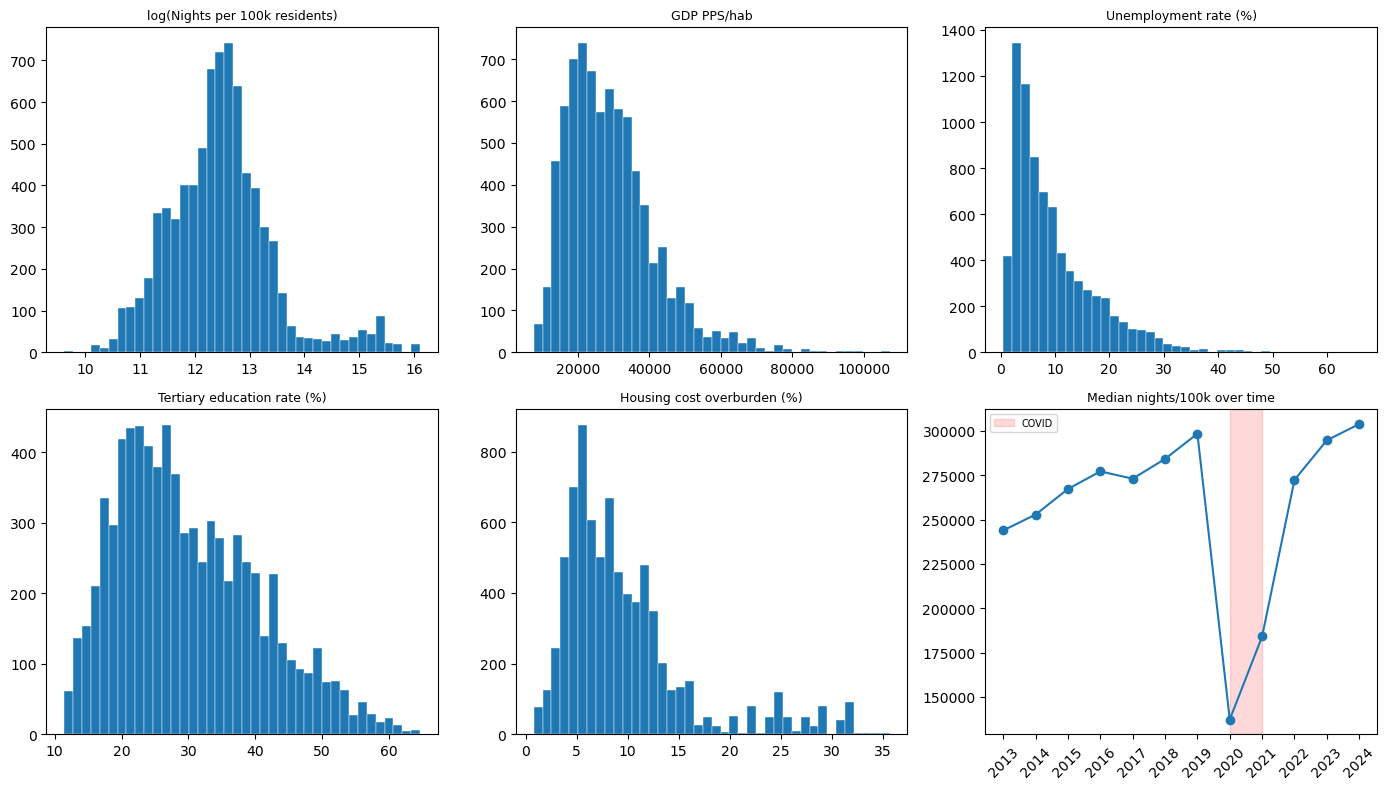

In [42]:
# --- EDA: distribution of outcome and covariates (Spec B, fully observed) ---
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

cols = ['nights_per_100k', 'gdp_pps_per_hab', 'unemployment_rate',
        'tertiary_edu_rate', 'housing_cost_overburden_rate']
labels = ['Nights per 100k residents', 'GDP PPS/hab', 'Unemployment rate (%)',
          'Tertiary education rate (%)', 'Housing cost overburden (%)']

for ax, col, lbl in zip(axes, cols, labels):
    ax.hist(np.log1p(panel_B[col]) if col == 'nights_per_100k' else panel_B[col],
            bins=40, edgecolor='white', linewidth=0.3)
    ax.set_title(f'log({lbl})' if col == 'nights_per_100k' else lbl, fontsize=9)
    ax.set_xlabel('')

# Timeline: median nights_per_100k across NUTS 2 by year
ax = axes[5]
ts = panel_B.groupby('TIME_PERIOD')['nights_per_100k'].median()
ax.plot(ts.index, ts.values, marker='o', linewidth=1.5)
ax.axvspan('2020', '2021', alpha=0.15, color='red', label='COVID')
ax.set_title('Median nights/100k over time', fontsize=9)
ax.legend(fontsize=7)
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


In [43]:
# --- Helper: prepare panel for linearmodels (MultiIndex: entity, time) ---
def prep_panel(df, entity='GEO', time='TIME_PERIOD'):
    d = df.copy()
    d[time] = pd.to_datetime(d[time], format='%Y')
    d = d.set_index([entity, time])
    # log-transform outcome (right-skewed count variable)
    d['log_nights'] = np.log1p(d['nights_per_100k'])
    if 'gdp_pps_per_hab' in d.columns:
        d['log_gdp'] = np.log(d['gdp_pps_per_hab'])
    return d

panel_A_m = prep_panel(panel_A.assign(nights_per_100k=panel_A['nights_per_100k']))
panel_B_m = prep_panel(panel_B)


In [47]:
# --- Spec A: Two-way FE (region + year), 2000–2024, GDP + unemployment ---
# log(nights_per_100k) ~ log(GDP/hab) + unemployment + EntityEffects + TimeEffects
# Standard errors clustered by region (accounts for within-region serial correlation).
# Note: covid/gfc dummies dropped — TimeEffects gives each year its own intercept,
# making year-specific dummies perfectly collinear (fully absorbed).

from linearmodels.panel import PanelOLS

# covid and gfc dummies are omitted: TimeEffects already gives each year its own
# intercept, so explicit year dummies are perfectly collinear with those effects.
formula_A = 'log_nights ~ log_gdp + unemployment_rate + EntityEffects + TimeEffects'
mod_A = PanelOLS.from_formula(formula_A, data=panel_A_m, drop_absorbed=True)
res_A = mod_A.fit(cov_type='clustered', cluster_entity=True)
print("=== Spec A: TWFE (2000–2024) ===")

print(res_A.summary.tables[1])

=== Spec A: TWFE (2000–2024) ===
                                 Parameter Estimates                                 
                   Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
-------------------------------------------------------------------------------------
log_gdp               0.3364     0.0836     4.0247     0.0001      0.1726      0.5003
unemployment_rate    -0.0040     0.0009    -4.6504     0.0000     -0.0057     -0.0023


In [48]:
# --- Spec B: Two-way FE (region + year), 2013–2024, all five covariates ---
formula_B = ('log_nights ~ log_gdp + unemployment_rate + tertiary_edu_rate '
             '+ housing_cost_overburden_rate + EntityEffects + TimeEffects')
mod_B = PanelOLS.from_formula(formula_B, data=panel_B_m, drop_absorbed=True)
res_B = mod_B.fit(cov_type='clustered', cluster_entity=True)
print("=== Spec B: TWFE (2013–2024) ===")
print(res_B.summary.tables[1])


=== Spec B: TWFE (2013–2024) ===
                                      Parameter Estimates                                       
                              Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
------------------------------------------------------------------------------------------------
log_gdp                          0.7767     0.1117     6.9546     0.0000      0.5578      0.9956
unemployment_rate               -0.0016     0.0004    -3.6230     0.0003     -0.0024     -0.0007
tertiary_edu_rate             6.521e-05     0.0033     0.0200     0.9841     -0.0063      0.0065
housing_cost_overburden_rate     0.0056     0.0030     1.8531     0.0639     -0.0003      0.0114


In [50]:
# --- Model fit summary ---
def model_stats(res, label):
    print(f"\n{'='*55}")
    print(f"  {label}")
    print(f"{'='*55}")
    print(f"  Within R²         : {res.rsquared_within:.4f}")
    print(f"  Overall R²        : {res.rsquared:.4f}")
    print(f"  F-statistic       : {res.f_statistic.stat:.2f}  (p = {res.f_statistic.pval:.4f})")
    print(f"  Obs               : {res.nobs:,.0f}")
    print(f"  Entities (regions): {res.entity_info.total:.0f}")
    print(f"  Time periods      : {res.time_info.total:.0f}")

model_stats(res_A, "Spec A — TWFE 2000–2024 (GDP + unemployment)")
model_stats(res_B, "Spec B — TWFE 2013–2024 (all covariates)")



  Spec A — TWFE 2000–2024 (GDP + unemployment)
  Within R²         : 0.2120
  Overall R²        : 0.1049
  F-statistic       : 871.12  (p = 0.0000)
  Obs               : 15,096
  Entities (regions): 199
  Time periods      : 25

  Spec B — TWFE 2013–2024 (all covariates)
  Within R²         : 0.0791
  Overall R²        : 0.0986
  F-statistic       : 205.80  (p = 0.0000)
  Obs               : 7,738
  Entities (regions): 199
  Time periods      : 12


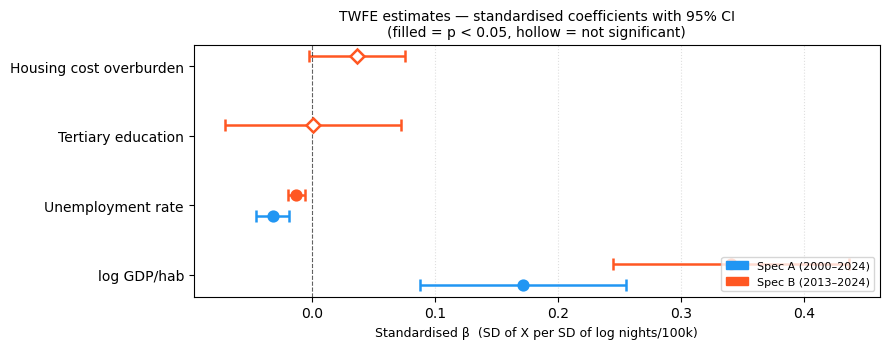

In [51]:
# --- Coefficient plot (redesigned) ---
# Problem: log_gdp coefficient (~0.3–0.8) is 100× larger than the others (~0.001–0.006),
# making a single-axis plot unreadable.
# Solution: standardised beta coefficients — multiply each raw coef by (SD of X / SD of y).
# This puts all variables on a common "one-SD-of-X → how many SDs of y" scale.

import matplotlib.patches as mpatches

def coef_df(result, spec_label, panel_df):
    """Return standardised and raw coefficients with 95% CI."""
    params  = result.params
    ci      = result.conf_int()
    y_std   = panel_df['log_nights'].std()
    rows = []
    for var in params.index:
        if var in ['Intercept', 'const']:
            continue
        # raw X std (use the modelling dataframe)
        x_std = panel_df[var].std() if var in panel_df.columns else 1.0
        beta_std = params[var] * x_std / y_std
        ci_lo_std = ci.loc[var, 'lower'] * x_std / y_std
        ci_hi_std = ci.loc[var, 'upper'] * x_std / y_std
        rows.append({
            'variable': var,
            'coef_raw':    params[var],
            'ci_lo_raw':   ci.loc[var, 'lower'],
            'ci_hi_raw':   ci.loc[var, 'upper'],
            'coef_std':    beta_std,
            'ci_lo_std':   ci_lo_std,
            'ci_hi_std':   ci_hi_std,
            'pval':        result.pvalues[var],
            'spec':        spec_label
        })
    return pd.DataFrame(rows)

df_A = coef_df(res_A, 'Spec A (2000–2024)', panel_A_m)
df_B = coef_df(res_B, 'Spec B (2013–2024)', panel_B_m)
df_plot = pd.concat([df_A, df_B], ignore_index=True)

# Variable display names
name_map = {
    'log_gdp':                       'log GDP/hab',
    'unemployment_rate':             'Unemployment rate',
    'tertiary_edu_rate':             'Tertiary education',
    'housing_cost_overburden_rate':  'Housing cost overburden',
}
df_plot['var_label'] = df_plot['variable'].map(name_map).fillna(df_plot['variable'])

colors  = {'Spec A (2000–2024)': '#2196F3', 'Spec B (2013–2024)': '#FF5722'}
offsets = {'Spec A (2000–2024)': -0.15,      'Spec B (2013–2024)':  0.15}

var_order = ['log GDP/hab', 'Unemployment rate', 'Tertiary education', 'Housing cost overburden']
vars_present = [v for v in var_order if v in df_plot['var_label'].values]

fig, ax = plt.subplots(figsize=(9, max(3.5, len(vars_present) * 0.9)))

for i, var in enumerate(vars_present):
    sub = df_plot[df_plot['var_label'] == var]
    for spec, grp in sub.groupby('spec'):
        row   = grp.iloc[0]
        y_pos = i + offsets[spec]
        col   = colors[spec]
        # marker: filled if p < 0.05, hollow otherwise
        marker = 'o' if row['pval'] < 0.05 else 'D'
        ax.errorbar(
            row['coef_std'], y_pos,
            xerr=[[row['coef_std'] - row['ci_lo_std']],
                  [row['ci_hi_std'] - row['coef_std']]],
            fmt=marker, color=col, capsize=4, linewidth=1.8,
            markersize=7, markerfacecolor=col if row['pval'] < 0.05 else 'white',
            markeredgewidth=1.8
        )

ax.axvline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.6)
ax.set_yticks(range(len(vars_present)))
ax.set_yticklabels(vars_present, fontsize=10)
ax.set_xlabel('Standardised β  (SD of X per SD of log nights/100k)', fontsize=9)
ax.set_title('TWFE estimates — standardised coefficients with 95% CI\n'
             '(filled = p < 0.05, hollow = not significant)', fontsize=10)

patches = [mpatches.Patch(color=c, label=s) for s, c in colors.items()]
ax.legend(handles=patches, fontsize=8, loc='lower right')
ax.grid(axis='x', linestyle=':', alpha=0.4)
plt.tight_layout()
plt.show()
